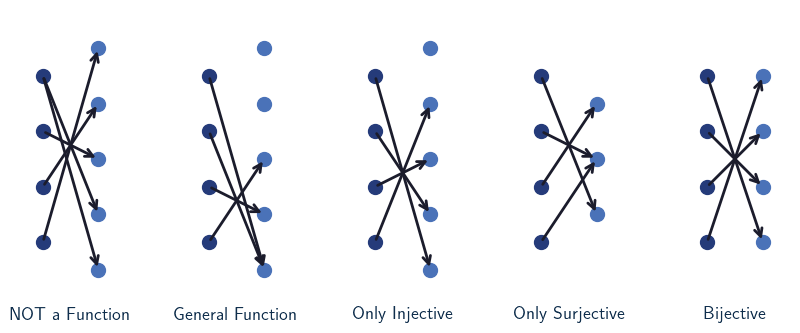

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import config.config as config

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "text.latex.preamble": r"\usepackage{amsmath}"
})

# === Positions ===
x_M = 0
x_N = 1

y_positions = [3.5, 2.5, 1.5, 0.5]  # Domain points (M)

# === Setup figure ===
fig, axes = plt.subplots(1, 5, figsize=(10, 6))
plt.subplots_adjust(wspace=0.5)

# === Labels for bottom titles ===
titles = [
    "NOT a Function",
    "General Function",
    "Only Injective",
    "Only Surjective",
    "Bijective"
]

# === Connection definitions ===
connections_list = [
    [(0, 4), (0, 3), (1, 2), (2, 1), (3, 0)],          # NOT a function
    [(0, 4), (1, 4), (2, 3), (3, 2)],                  # General function
    [(0, 4), (1, 3), (2, 2), (3, 1)],                  # Injective (not surjective)
    [(0, 2), (1, 1), (2, 0), (3, 1)],                  # Surjective (only 3 in N)
    [(0, 3), (1, 2), (2, 1), (3, 0)]                   # Bijective (4 in N)
]

# === Colors ===
node_M_color = '#253b7a'      # Dark-medium blue
node_N_color = '#4a72b8'      # Medium blue
line_color = '#1b1c2c'        # Darkest blue
title_color = '#0f2e4c'       # Elegant very dark blue

# === Main plotting loop ===
for i, (ax, title, connections) in enumerate(zip(axes, titles, connections_list)):
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.9, 4.7)  # Extended y-limit to show extra point when present
    ax.set_aspect('equal')
    ax.axis('off')

    # === Define codomain positions dynamically ===
    if i < 3:
        y_positions_N = [4, 3, 2, 1, 0]  # First 3 panels have 5 in N
    elif i == 3:
        y_positions_N = [3, 2, 1]         # Surjective has 3 in N
    else:
        y_positions_N = [3.5, 2.5, 1.5, 0.5]  # Bijective has 4 in N

    # === Plot nodes ===
    for y in y_positions:
        ax.plot(x_M, y, 'o', color=node_M_color, markersize=10)  # Domain
    for y in y_positions_N:
        ax.plot(x_N, y, 'o', color=node_N_color, markersize=10)  # Codomain

    # === Draw connections ===
    for start_idx, end_idx in connections:
        ax.annotate("",
                    xy=(x_N, y_positions_N[end_idx]),
                    xytext=(x_M, y_positions[start_idx]),
                    arrowprops=dict(arrowstyle="->", color=line_color, lw=2))

    # === Bottom Title ===
    ax.text(0.5, -0.9, title, fontsize=13, color=title_color, ha='center')

# === Layout (adjusted top space) ===
# plt.tight_layout(rect=[0, 0, 1, 0.85])

fig.savefig(os.path.join(config.save_dir, "examples_injective_surjective_bijective.pdf"))
plt.show()